In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Hyperbolic PDEs #



Solve the linear advection equation by evolving an initial waveform in a periodic grid.

@autor:     Dario Hug

@date:      18.11.2024

Use the different methods seen in the lecture:
- Loser method
- LAX
- Upwind
- LAX-Wendroff

See how the waveform behaves after passing through the grid multiple times and compare the results you get with the different methods and different values for c.


## Looser Method ##

$ \rho^{n+1}_j = \rho^n_j - \frac{1}{2} C (\rho^n_{j+1} - \rho^n_{j-1}) $ 

This method is unstable independent from $ C $

In [11]:
def looser(rho, c):
    rho_new = rho.copy()
    for i in range(len(rho)):
        forward = rho[(i + 1) % len(rho)]
        backward = rho[(i - 1) % len(rho)]
        rho_new[i] = rho[i] - c / 2 * (forward - backward)
    return rho_new

## LAX Method ##

$ \rho^{n+1}_j = \frac{1}{2} (\rho^n_{j+1} + \rho^n_{j-1}) - C \frac{1}{2} (\rho^n_{j+1} - \rho^n_{j-1}) $

After the Von Neuman test, this method will be stable as long as $ |C| < 1 $.

In [12]:
def lax(rho, c):
    rho_new = rho.copy()
    for i in range(len(rho)):
        forward = rho[(i + 1) % len(rho)]
        backward = rho[(i - 1) % len(rho)]
        rho_new[i] = 0.5 * (forward + backward) - c / 2 * (forward - backward)
    return rho_new

## Upwind Method ##

$ 
\rho^{n+1}_j = 
\begin{cases}
    \rho_j^n - c(\rho^n_j - \rho^n_{j-1}) ,& \text{if } u > 0\\
    \rho_j^n - c(\rho^n_{j+1} - \rho^n_{j}) ,& \text{if } u < 0 \text{  not used in our code}
\end{cases}
$

-> First order Upwind


In [13]:
def upwind(rho, c):
    rho_new = rho.copy()
    for i in range(len(rho)):
        current = rho[i]
        backward = rho[(i - 1) % len(rho)]
        rho_new[i] = current - c * (current - backward)
    return rho_new

## LAX Wendroff Method ##

$ \rho^n_{j+1} = \frac{1}{2} c (1 + c) \rho^n_{j-1} + (1-c²)\rho^n_j - \frac{1}{2} c (1-c)\rho^n_{j+1} $ if $ n > 0 $

In [14]:
def laxwend(rho, c):
    rho_new = rho.copy()
    for i in range(len(rho)):
        forward = rho[(i + 1) % len(rho)]
        current = rho[i]
        backward = rho[(i - 1) % len(rho)]
        rho_new[i] = (c / 2) * (1 + c) * backward + (1 - c**2) * current - (c / 2) * (1 - c) * forward
    return rho_new

## Main ##

$ c = \frac{\Delta x  * u}{\Delta t} $ 

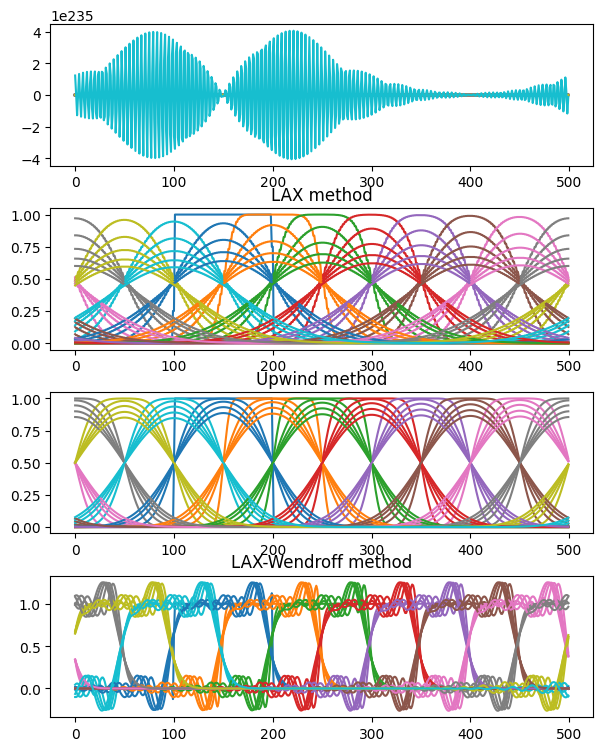

In [18]:

N = 500

rho = np.zeros(N)
rho[int(N/5):int(2*N/5)] = 1

c = 0.5

tend = 5000

def evolve(rho,c,method, ax,tend):
    for i in range(tend):
        rho = method(rho, c)
        if i % 100 == 0:
            ax.plot(rho,label = i)

fig, ax = plt.subplots(4,1, figsize =(7,9))
ax[1].set_title("LAX method")
ax[2].set_title("Upwind method")
ax[3].set_title("LAX-Wendroff method")

for idx, method in enumerate([looser, lax, upwind, laxwend]):
    evolve(rho.copy(), c, method, ax[idx], tend)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.3)
plt.show()
fig.savefig("results_template.png",dpi=350)
